In [7]:
import pandas as pd 
import numpy as np
dataset = pd.read_csv("labeled_data.csv")
dataset.head()

,Unnamed: 0,count,hate_speech,offensive_language,neither,class,tweet
0,0,3,0,0,3,2,!!! RT @mayasolovely: As a woman you shouldn't...
1,1,3,0,3,0,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,2,3,0,3,0,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,3,3,0,2,1,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,4,6,0,6,0,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...


In [8]:
dataset.describe()

,Unnamed: 0,count,hate_speech,offensive_language,neither,class
count,24783.000000,24783.000000,24783.000000,24783.000000,24783.000000,24783.000000
mean,12681.192027,3.243473,0.280515,2.413711,0.549247,1.110277
std,7299.553863,0.883060,0.631851,1.399459,1.113299,0.462089
min,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000
25%,6372.500000,3.000000,0.000000,2.000000,0.000000,1.000000
50%,12703.000000,3.000000,0.000000,3.000000,0.000000,1.000000
75%,18995.500000,3.000000,0.000000,3.000000,0.000000,1.000000
max,25296.000000,9.000000,7.000000,9.000000,9.000000,2.000000


In [9]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24783 entries, 0 to 24782
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Unnamed: 0          24783 non-null  int64 
 1   count               24783 non-null  int64 
 2   hate_speech         24783 non-null  int64 
 3   offensive_language  24783 non-null  int64 
 4   neither             24783 non-null  int64 
 5   class               24783 non-null  int64 
 6   tweet               24783 non-null  object
dtypes: int64(6), object(1)
memory usage: 1.3+ MB


In [10]:
dataset.isnull()

,Unnamed: 0,count,hate_speech,offensive_language,neither,class,tweet
0,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...
24778,False,False,False,False,False,False,False
24779,False,False,False,False,False,False,False
24780,False,False,False,False,False,False,False
24781,False,False,False,False,False,False,False


In [11]:
dataset['Category'] = dataset['Classification'].map({ 0: "Toxic Content",
                                1: "Abusive Speech",
                                2: "Neutral Expression"})

In [12]:
dataset

,Unnamed: 0,count,hate_speech,offensive_language,neither,class,tweet,Label
0,0,3,0,0,3,2,!!! RT @mayasolovely: As a woman you shouldn't...,Neither hate nor offensive
1,1,3,0,3,0,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...,Offensive Language
2,2,3,0,3,0,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...,Offensive Language
3,3,3,0,2,1,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...,Offensive Language
4,4,6,0,6,0,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...,Offensive Language
...,...,...,...,...,...,...,...,...
24778,25291,3,0,2,1,1,you's a muthaf***in lie &#8220;@LifeAsKing: @2...,Offensive Language
24779,25292,3,0,1,2,2,"you've gone and broke the wrong heart baby, an...",Neither hate nor offensive
24780,25294,3,0,3,0,1,young buck wanna eat!!.. dat nigguh like I ain...,Offensive Language
24781,25295,6,0,6,0,1,youu got wild bitches tellin you lies,Offensive Language


In [13]:
data = dataset[['tweet', 'Category']]


In [14]:
data

,tweet,Label
0,!!! RT @mayasolovely: As a woman you shouldn't...,Neither hate nor offensive
1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...,Offensive Language
2,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...,Offensive Language
3,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...,Offensive Language
4,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...,Offensive Language
...,...,...
24778,you's a muthaf***in lie &#8220;@LifeAsKing: @2...,Offensive Language
24779,"you've gone and broke the wrong heart baby, an...",Neither hate nor offensive
24780,young buck wanna eat!!.. dat nigguh like I ain...,Offensive Language
24781,youu got wild bitches tellin you lies,Offensive Language


In [15]:
import re 
import nltk
import string

In [25]:
from nltk.corpus import stopwords
stopwords = set(stopwords.words('english'))
steamer = nltk.SnowballStemmer('english')

In [17]:
def clean_data(text):
    text = str(text).lower()
    text = re.sub('https?://\S+|www\.S+', '', text)
    text = re.sub('\[.*?\]', '', text)
    text = re.sub("<.*?>+", '', text)
    text = re.sub('[%s]' %re.escape(string.punctuation), '', text)
    text = re.sub('\n' , '', text)
    text = re.sub('\w*\d\w*', '', text)


    text = [word for word in text.split(' ') if word not in stopwords]  
    text = ' '.join(text)

    text = [steamer.stem(word) for word in text.split(' ')]
    text = ' '.join(text)
    return text

In [26]:
data['tweet'] = data['tweet'].apply(clean_data)

C:\Users\Apple\AppData\Local\Temp\ipykernel_5780\3370867953.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['tweet'] = data['tweet'].apply(clean_data)


In [27]:
data

,tweet,Label
0,rt mayasolov woman shouldnt complain clean ho...,Neither hate nor offensive
1,rt boy dat coldtyga dwn bad cuffin dat hoe ...,Offensive Language
2,rt urkindofbrand dawg rt ever fuck bitch sta...,Offensive Language
3,rt cganderson vivabas look like tranni,Offensive Language
4,rt shenikarobert shit hear might true might f...,Offensive Language
...,...,...
24778,yous muthafin lie coreyemanuel right tl tras...,Offensive Language
24779,youv gone broke wrong heart babi drove redneck...,Neither hate nor offensive
24780,young buck wanna eat dat nigguh like aint fuck...,Offensive Language
24781,youu got wild bitch tellin lie,Offensive Language


In [29]:
x = np.array(data['tweet'])
y = np.array(data['Category'])

In [30]:
x

array([' rt mayasolov woman shouldnt complain clean hous amp man alway take trash',
       ' rt  boy dat coldtyga dwn bad cuffin dat hoe  place',
       ' rt urkindofbrand dawg rt  ever fuck bitch start cri confus shit',
       ..., 'young buck wanna eat dat nigguh like aint fuckin dis',
       'youu got wild bitch tellin lie',
       'ruffl  ntac eileen dahlia  beauti color combin pink orang yellow amp white coll '],
      dtype=object)

In [31]:
y

array(['Neither hate nor offensive', 'Offensive Language',
       'Offensive Language', ..., 'Offensive Language',
       'Offensive Language', 'Neither hate nor offensive'], dtype=object)

In [32]:
pip install -U scikit-learn

     ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
     ---------------------------------------- 0.0/8.3 MB 660.6 kB/s eta 0:00:13
     ---------------------------------------- 0.1/8.3 MB 825.8 kB/s eta 0:00:10
      --------------------------------------- 0.1/8.3 MB 819.2 kB/s eta 0:00:10
      --------------------------------------- 0.1/8.3 MB 819.2 kB/s eta 0:00:10
      --------------------------------------- 0.1/8.3 MB 819.2 kB/s eta 0:00:10
      --------------------------------------- 0.2/8.3 MB 734.2 kB/s eta 0:00:11
     - -------------------------------------- 0.2/8.3 MB 801.7 kB/s eta 0:00:11
     - -------------------------------------- 0.3/8.3 MB 684.6 kB/s eta 0:00:12
     - -------------------------------------- 0.3/8.3 MB 787.7 kB/s eta 0:00:11
     - -------------------------------------- 0.4/8.3 MB 859.0 kB/s eta 0:00:10
     -- ------------------------------------- 0.5/8.3 MB 880.6 kB/s eta 0:00:09
     -- ------------------------------------- 0.5

In [33]:
from sklearn.feature_extraction.text import CountVectorizer
cv = CountVectorizer()

In [34]:
x = cv.fit_transform(x)

In [35]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

In [36]:
x_train

<17348x25693 sparse matrix of type '<class 'numpy.int64'>'
	with 138528 stored elements in Compressed Sparse Row format>

In [38]:
len(y_train)

17348

In [39]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier()

In [40]:
dt.fit(x_train, y_train)

DecisionTreeClassifier()

In [41]:
y_pred = dt.predict(x_test)

In [42]:
y_pred

array(['Offensive Language', 'Offensive Language', 'Offensive Language',
       ..., 'Neither hate nor offensive', 'Offensive Language',
       'Hate speech'], dtype=object)

In [43]:
y_test

array(['Offensive Language', 'Offensive Language',
       'Neither hate nor offensive', ..., 'Offensive Language',
       'Offensive Language', 'Offensive Language'], dtype=object)

In [56]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score

In [57]:
cn = confusion_matrix(y_test, y_pred)
cn

array([[ 136,   36,  255],
       [  33, 1029,  199],
       [ 205,  200, 5342]], dtype=int64)

In [58]:
acc = accuracy_score(y_test, y_pred)
acc

0.8751849361129792

In [59]:
acc*100

87.51849361129793

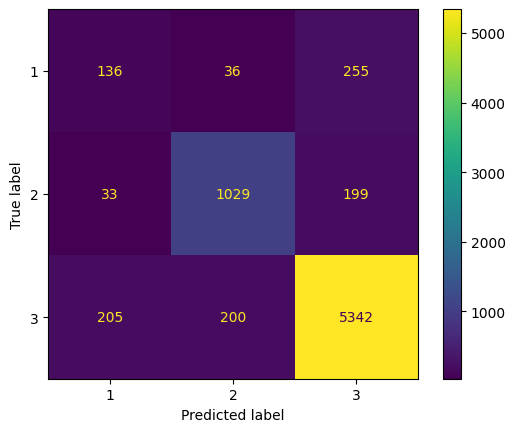

In [62]:
cn_display = ConfusionMatrixDisplay(confusion_matrix = cn, display_labels = [1, 2, 3])
import matplotlib.pyplot as plt

cn_display.plot()
plt.show()